``scp -r teampc@sl07.vc.cit.tum.de:~/LVSM-VAE/notebooks/results/performance_metrics/ ~/LVSM-VAE/notebooks/results/``

In [1]:
import os
import sys
project_root = os.path.abspath("..")
sys.path.append(project_root)

In [17]:
root = project_root + r"/notebooks/results/"
# dir = "performance_metrics"
FOLDER_A = root + "performance_metrics"
FOLDER_B = root + "performance_metrics_4ctx"
FOLDER_C = root + "performance_metrics_8ctx"

LABEL_A = "LVSM-VAE trained on 2 references"
LABEL_B = "LVSM-VAE fine-tuned on 4 references"
LABEL_C = "LVSM-VAE fine-tuned on 8 references"

In [15]:
import pandas as pd
# ---- "Folder 4" (from figure extraction): PRoPE + CamRay ----
LABEL_D = "LVSM PRoPE - trained on 2 references"
df_d = pd.DataFrame([
    {"reference_views": 2,  "psnr": 21.520539, "ssim": 0.689852, "lpips": 0.163170, "source": LABEL_D},
    {"reference_views": 4,  "psnr": 23.503301, "ssim": 0.732624, "lpips": 0.126577, "source": LABEL_D},
    {"reference_views": 8,  "psnr": 23.649092, "ssim": 0.741586, "lpips": 0.144873, "source": LABEL_D},
    {"reference_views": 16, "psnr": 23.182560, "ssim": 0.729366, "lpips": 0.201505, "source": LABEL_D},
]).sort_values("reference_views").reset_index(drop=True)


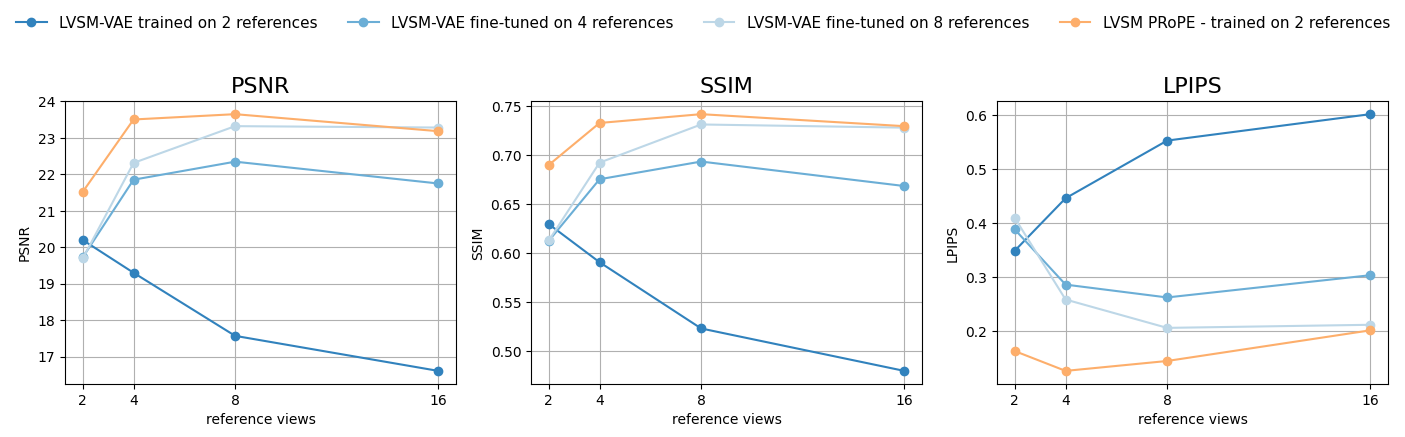

In [18]:
# This script loads metrics from folders with context*_res.txt files
# and plots PSNR, SSIM, LPIPS together for comparison.


import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

fname_re = re.compile(r"context(\d+)_res\.txt$", re.IGNORECASE)

def load_folder(folder, label):
    rows = []
    files = sorted(glob.glob(os.path.join(folder, "context*_res.txt")))

    if not files:
        raise RuntimeError(f"No files found in {folder}")

    for fp in files:
        base = os.path.basename(fp)
        m = fname_re.search(base)
        if not m:
            continue

        ctx = int(m.group(1))

        with open(fp, "r", encoding="utf-8", errors="ignore") as f:
            txt = f.read()

        psnr_m  = re.search(r"\bpsn(r)?\s*:\s*([0-9]*\.?[0-9]+)", txt, re.IGNORECASE)
        ssim_m  = re.search(r"\bssim\s*:\s*([0-9]*\.?[0-9]+)", txt, re.IGNORECASE)
        lpips_m = re.search(r"\blpips\s*:\s*([0-9]*\.?[0-9]+)", txt, re.IGNORECASE)

        rows.append({
            "reference_views": ctx,
            "psnr":  float(psnr_m.group(2)) if psnr_m else None,
            "ssim":  float(ssim_m.group(1)) if ssim_m else None,
            "lpips": float(lpips_m.group(1)) if lpips_m else None,
            "source": label,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"No valid rows parsed in {folder}")
    return df.sort_values("reference_views").reset_index(drop=True)


df_a = load_folder(FOLDER_A, LABEL_A)
df_b = load_folder(FOLDER_B, LABEL_B)
df_c = load_folder(FOLDER_C, LABEL_C)

colors = {
    "vae_encode":  "#bdd7e7",
    "vae_forward": "#6baed6",
    "vae_decode":  "#3182bd",
    "px_total":    "#fdae6b",
}

def plot_metric(metric):
    plt.figure()
    plt.plot(df_a["reference_views"], df_a[metric], marker="o", label=LABEL_A, color=colors["vae_decode"])
    plt.plot(df_b["reference_views"], df_b[metric], marker="o", label=LABEL_B, color=colors["vae_forward"])
    plt.plot(df_c["reference_views"], df_c[metric], marker="o", label=LABEL_C, color=colors["vae_encode"])
    plt.plot(df_d["reference_views"], df_d[metric], marker="o", label=LABEL_D, color=colors["px_total"])
    plt.xlabel("reference views")
    plt.ylabel(metric.upper())
    plt.title(metric.upper())
    plt.xticks(sorted(set(df_a["reference_views"]) | set(df_b["reference_views"])))
    plt.grid(True)
    plt.legend()
    plt.show()

# plot_metric("psnr")
# plot_metric("ssim")
# plot_metric("lpips")

def plot_all_metrics():
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

    metrics = ["psnr", "ssim", "lpips"]
    titles = ["PSNR", "SSIM", "LPIPS"]

    dfs = [
        (df_a, LABEL_A, colors["vae_decode"]),
        (df_b, LABEL_B, colors["vae_forward"]),
        (df_c, LABEL_C, colors["vae_encode"]),
        (df_d, LABEL_D, colors["px_total"]),
    ]

    all_x = sorted(
        set(df_a["reference_views"]) |
        set(df_b["reference_views"]) |
        set(df_c["reference_views"]) |
        set(df_d["reference_views"])
    )

    for ax, metric, title in zip(axes, metrics, titles):
        for df, label, color in dfs:
            ax.plot(
                df["reference_views"],
                df[metric],
                marker="o",
                label=label,
                color=color,
            )

        ax.set_title(title, fontsize=16)   # larger titles
        ax.set_xlabel("reference views")
        ax.set_ylabel(title)
        ax.set_xticks(all_x)
        ax.grid(True)

    # ---- shared legend above all plots ----
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(dfs),
        frameon=False,
        bbox_to_anchor=(0.5, 1.10),
        fontsize=11,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_all_metrics()


In [4]:
import os
import pandas as pd

CONTEXTS = range(2, 17)  # 2..16
OUT_CSV = "/home/felix/LVSM-VAE/notebooks/results/one_scene_eval/ssim_extremes_and_average_ids.csv"


def pick_rows(df: pd.DataFrame, k: int = 15):   # <-- 15
    df = df.copy()
    df["SSIM"] = pd.to_numeric(df["SSIM"], errors="coerce")
    df = df.dropna(subset=["ID", "SSIM"])

    if df.empty:
        return None

    max_df = df.sort_values("SSIM", ascending=False).head(k)
    min_df = df.sort_values("SSIM", ascending=True).head(k)

    mean_ssim = df["SSIM"].mean()
    df["_dist_to_mean"] = (df["SSIM"] - mean_ssim).abs()
    avg_df = df.sort_values("_dist_to_mean", ascending=True).head(k)

    out = {"mean_ssim": mean_ssim}

    for i in range(k):
        if i < len(max_df):
            out[f"max{i+1}_id"] = max_df.iloc[i]["ID"]
            out[f"max{i+1}_ssim"] = float(max_df.iloc[i]["SSIM"])
        else:
            out[f"max{i+1}_id"] = None
            out[f"max{i+1}_ssim"] = None

        if i < len(min_df):
            out[f"min{i+1}_id"] = min_df.iloc[i]["ID"]
            out[f"min{i+1}_ssim"] = float(min_df.iloc[i]["SSIM"])
        else:
            out[f"min{i+1}_id"] = None
            out[f"min{i+1}_ssim"] = None

        if i < len(avg_df):
            out[f"avg{i+1}_id"] = avg_df.iloc[i]["ID"]
            out[f"avg{i+1}_ssim"] = float(avg_df.iloc[i]["SSIM"])
        else:
            out[f"avg{i+1}_id"] = None
            out[f"avg{i+1}_ssim"] = None

    return out


def process_folder(folder: str, label: str, k: int = 15):  # <-- 15
    records = []

    for c in CONTEXTS:
        path = os.path.join(folder, f"context{c}.csv")
        if not os.path.exists(path):
            continue

        df = pd.read_csv(path)
        if "ID" not in df.columns or "SSIM" not in df.columns:
            continue

        picks = pick_rows(df, k=k)
        if picks is None:
            continue

        records.append({
            "folder": label,
            "reference_views": c,
            **picks,
        })

    return pd.DataFrame(records)


df_a = process_folder(FOLDER_A, LABEL_A, k=15)  # <-- 15
df_b = process_folder(FOLDER_B, LABEL_B, k=15)  # <-- 15

out = pd.concat([df_a, df_b], ignore_index=True)
out = out.sort_values(["reference_views", "folder"]).reset_index(drop=True)

print(out.to_string(index=False))
out.to_csv(OUT_CSV, index=False)

print(f"\nSaved: {OUT_CSV}")


                             folder  reference_views  mean_ssim          max1_id  max1_ssim          min1_id  min1_ssim          avg1_id  avg1_ssim          max2_id  max2_ssim          min2_id  min2_ssim          avg2_id  avg2_ssim          max3_id  max3_ssim          min3_id  min3_ssim          avg3_id  avg3_ssim          max4_id  max4_ssim          min4_id  min4_ssim          avg4_id  avg4_ssim          max5_id  max5_ssim          min5_id  min5_ssim          avg5_id  avg5_ssim          max6_id  max6_ssim          min6_id  min6_ssim          avg6_id  avg6_ssim          max7_id  max7_ssim          min7_id  min7_ssim          avg7_id  avg7_ssim          max8_id  max8_ssim          min8_id  min8_ssim          avg8_id  avg8_ssim          max9_id  max9_ssim          min9_id  min9_ssim          avg9_id  avg9_ssim         max10_id  max10_ssim         min10_id  min10_ssim         avg10_id  avg10_ssim         max11_id  max11_ssim         min11_id  min11_ssim         avg11_id  avg11_ssim       

In [5]:
import os
import pandas as pd

# ===== CONFIG =====
CTX_BAD = 2
CTX_GOOD = 8
TOP_K = 5
BAD_QUANTILE = 0.20   # bottom 20% = "very bad"
# ==================

path_bad = os.path.join(FOLDER_B, f"context{CTX_BAD}.csv")
path_good = os.path.join(FOLDER_B, f"context{CTX_GOOD}.csv")

# Silently skip if files are missing
if not (os.path.exists(path_bad) and os.path.exists(path_good)):
    print("Required CSVs not found, nothing to do.")
else:
    df_bad = pd.read_csv(path_bad)
    df_good = pd.read_csv(path_good)

    # Keep relevant columns only
    df_bad = df_bad[["ID", "SSIM"]].copy()
    df_good = df_good[["ID", "SSIM"]].copy()

    # Ensure numeric
    df_bad["SSIM"] = pd.to_numeric(df_bad["SSIM"], errors="coerce")
    df_good["SSIM"] = pd.to_numeric(df_good["SSIM"], errors="coerce")

    df_bad = df_bad.dropna()
    df_good = df_good.dropna()

    # Join on ID
    merged = df_bad.merge(
        df_good,
        on="ID",
        suffixes=("_ctx2", "_ctx8")
    )

    if merged.empty:
        print("No overlapping IDs between context 2 and 8.")
    else:
        # Define "very bad" at context 2
        bad_threshold = merged["SSIM_ctx2"].quantile(BAD_QUANTILE)

        candidates = merged[merged["SSIM_ctx2"] <= bad_threshold].copy()

        # Improvement score
        candidates["ssim_gain"] = (
            candidates["SSIM_ctx8"] - candidates["SSIM_ctx2"]
        )

        top5 = (
            candidates
            .sort_values("ssim_gain", ascending=False)
            .head(TOP_K)
        )

        print("\nTop 5 IDs: bad at 2 views → much better at 8 views\n")
        print(
            top5[["ID", "SSIM_ctx2", "SSIM_ctx8", "ssim_gain"]]
            .to_string(index=False)
        )



Top 5 IDs: bad at 2 views → much better at 8 views

              ID  SSIM_ctx2  SSIM_ctx8  ssim_gain
31a642fe4cd1e232   0.334705   0.655077   0.320371
18a86c01aaaaaa8b   0.424087   0.713537   0.289450
f27cb10112666229   0.455270   0.741160   0.285891
ca896b9824333d2f   0.159376   0.444797   0.285422
9f2d777199df4930   0.407513   0.682152   0.274639


In [37]:
import math
import matplotlib.pyplot as plt
import torch


def plot_lvsm_scene_nice_fig(
    *,
    ref_px: torch.Tensor,
    out_px: torch.Tensor,
    tar_px: torch.Tensor,
    refs_per_row: int = 4,
    img_size: float = 2.8,
    divider_lw: float = 2.0,
):
    """
    Same layout as before, but:
      - returns (fig)
      - does NOT call plt.show()
    """
    # ---- drop batch dim if present ----
    if ref_px.ndim == 5:
        ref_px = ref_px.squeeze(0)
    if out_px.ndim == 5:
        out_px = out_px.squeeze(0)
    if tar_px.ndim == 5:
        tar_px = tar_px.squeeze(0)

    Vref = ref_px.shape[0]
    Vtar = out_px.shape[0]

    ref_rows = math.ceil(Vref / refs_per_row)
    n_rows = max(ref_rows, 2)

    left_cols = refs_per_row
    right_cols = Vtar
    total_cols = left_cols + right_cols

    fig_w = total_cols * img_size
    fig_h = n_rows * img_size

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = fig.add_gridspec(
        nrows=n_rows,
        ncols=total_cols,
        wspace=0.05,
        hspace=0.35,  # leaves space for titles
    )

    # LEFT: refs
    for i in range(Vref):
        r = i // refs_per_row
        c = i % refs_per_row
        ax = fig.add_subplot(gs[r, c])
        ax.imshow(ref_px[i].detach().cpu().clamp(0, 1))
        ax.axis("off")

    ax_ref_title = fig.add_subplot(gs[0, :left_cols])
    ax_ref_title.set_title("Reference views", fontsize=28, pad=14)
    ax_ref_title.axis("off")

    # RIGHT TOP: preds
    for i in range(Vtar):
        ax = fig.add_subplot(gs[0, left_cols + i])
        ax.imshow(out_px[i].detach().cpu().clamp(0, 1))
        ax.axis("off")

    ax_pred_title = fig.add_subplot(gs[0, left_cols:])
    ax_pred_title.set_title("Predictions", fontsize=28, pad=14)
    ax_pred_title.axis("off")

    # RIGHT BOTTOM: GT
    for i in range(Vtar):
        ax = fig.add_subplot(gs[1, left_cols + i])
        ax.imshow(tar_px[i].detach().cpu().clamp(0, 1))
        ax.axis("off")

    ax_gt_title = fig.add_subplot(gs[1, left_cols:])
    ax_gt_title.set_title("GT", fontsize=28, pad=14)
    ax_gt_title.axis("off")

    # vertical divider (figure coords)
    divider_x = left_cols / total_cols
    fig.add_artist(
        plt.Line2D(
            [divider_x, divider_x],
            [0.02, 0.98],
            transform=fig.transFigure,
            color="black",
            linewidth=divider_lw,
            alpha=0.8,
        )
    )

    fig.tight_layout()
    return fig


In [23]:
from types import SimpleNamespace
from main import LVSMLauncher, LVSMLauncherConfig

import os
import json
import time
from pathlib import Path
from functools import lru_cache
from typing import Any, Dict, Optional, Tuple

import torch
from einops import rearrange
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity

from src.models.lvsm_decoder_only import LVSMDecoderOnlyModel
from src.data.torch_latent_dataset import _as_chw_latent, _normalize_poses_identity_unit_distance

import yaml

from types import SimpleNamespace
import sys
import os
project_root = os.path.abspath("..")
sys.path.append(project_root)

import re

from src.configs.lvsm_decoder_only_config import (
    LVSMDecoderOnlyModelConfig,
    RayEncodingType,
    PosEncType,
)
from src.prope.utils.transformer import (
    TransformerEncoderConfig,
    TransformerEncoderLayerConfig,
)
from main import LVSMLauncher
from main import LVSMLauncher, LVSMLauncherConfig


def _convert_poses(poses: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    b = poses.shape[0]
    intrinsics = torch.eye(3).repeat(b, 1, 1)
    fx, fy, cx, cy = poses[:, :4].T
    intrinsics[:, 0, 0] = fx
    intrinsics[:, 1, 1] = fy
    intrinsics[:, 0, 2] = cx
    intrinsics[:, 1, 2] = cy

    w2c = torch.eye(4).repeat(b, 1, 1)
    w2c[:, :3] = poses[:, 6:].view(b, 3, 4)
    return w2c.inverse(), intrinsics


class OneSceneEvaluatorIndexed:
    """
    Uses an existing mapping: scene_id -> torch filename (chunk),
    and discovers idx-in-file lazily and caches it.

    - No DataLoader
    - LRU caches chunk loads
    - Can swap checkpoints with set_checkpoint()
    """

    def __init__(
        self,
        *,
        ckpt_path: Optional[str],
        torch_root: str,
        scene_to_file_index_path: str,   # <-- your json mapping scene_id -> "000103.torch"
        launcher_cls,
        launcher_cfg,
        model_cfg,
        device: Optional[str] = None,
        chunk_cache_size: int = 8,
        file_idx_cache_size: int = 64,   # how many files' (scene_id->idx) maps to keep
    ):
        self.torch_root = str(torch_root)
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        # --- load the scene_id -> file mapping (fast) ---
        with open(scene_to_file_index_path, "r") as f:
            self.scene_to_file: Dict[str, str] = json.load(f)

        # --- launcher (VAE + preprocess/decode) ---
        self.launcher = launcher_cls(launcher_cfg)
        self.launcher.device = self.device

        # --- model (weights can be swapped) ---
        self.model = LVSMDecoderOnlyModel(model_cfg).to(self.device)
        self.model.eval()
        self.ckpt_path = None
        self.load_report = None
        if ckpt_path is not None:
            self.set_checkpoint(ckpt_path)

        # --- metrics ---
        self.psnr_fn = PeakSignalNoiseRatio(data_range=1.0)
        self.ssim_fn = StructuralSimilarityIndexMeasure(data_range=1.0)
        self.lpips_fn = LearnedPerceptualImagePatchSimilarity(net_type="alex", normalize=True)

        # --- cache eval indices ---
        self._eval_index_cache: Dict[str, Dict[str, Any]] = {}

        # --- cache loading .torch chunks ---
        @lru_cache(maxsize=chunk_cache_size)
        def _load_chunk(path: str):
            return torch.load(path, map_location="cpu")
        self._load_chunk = _load_chunk

        # --- cache per-file scene_id -> idx map (built lazily) ---
        @lru_cache(maxsize=file_idx_cache_size)
        def _file_key_to_idx(file_path: str) -> Dict[str, int]:
            scenes = self._load_chunk(file_path)
            return {s["key"]: i for i, s in enumerate(scenes) if "key" in s}
        self._file_key_to_idx = _file_key_to_idx

    def set_checkpoint(self, ckpt_path: str) -> Dict[str, Any]:
        self.ckpt_path = str(ckpt_path)
        ckpt = torch.load(self.ckpt_path, map_location="cpu", weights_only=True)
        state_dict = ckpt.get("model", ckpt)
        state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}

        missing, unexpected = self.model.load_state_dict(state_dict, strict=False)
        self.model.eval()
        self.load_report = {"missing_keys": missing, "unexpected_keys": unexpected}
        return self.load_report

    def _get_eval_index(self, eval_index_path: str) -> Dict[str, Any]:
        eval_index_path = str(eval_index_path)
        if eval_index_path not in self._eval_index_cache:
            with open(eval_index_path, "r") as f:
                self._eval_index_cache[eval_index_path] = json.load(f)
        return self._eval_index_cache[eval_index_path]

    def _load_scene_and_spec(self, scene_id: str, eval_index_path: str):
        index = self._get_eval_index(eval_index_path)
        if scene_id not in index or index[scene_id] is None:
            raise KeyError(f"scene_id={scene_id} not found (or None) in {eval_index_path}")
        spec = index[scene_id]

        if scene_id not in self.scene_to_file:
            raise KeyError(f"scene_id={scene_id} not found in scene_to_file index")

        file_name = self.scene_to_file[scene_id]
        file_path = os.path.join(self.torch_root, file_name)

        key_to_idx = self._file_key_to_idx(file_path)
        if scene_id not in key_to_idx:
            raise KeyError(f"scene_id={scene_id} not found inside {file_name}")

        scenes = self._load_chunk(file_path)
        scene = scenes[key_to_idx[scene_id]]
        return scene, spec

    def _make_batch_from_scene(self, scene: Dict[str, Any], spec: Dict[str, Any]):
        context_ids = list(spec["context"])
        target_ids  = list(spec["target"])
        ids = [i for i in (context_ids + target_ids) if i < len(scene["images"])]

        input_views = len(context_ids)
        if len(ids) < input_views:
            raise ValueError(f"have {len(ids)} < input_views {input_views} after filtering ids")

        latents = torch.stack([_as_chw_latent(scene["images"][i]) for i in ids])
        latents = latents.permute(0, 2, 3, 1).contiguous()

        c2ws, Ks = _convert_poses(scene["cameras"][ids])
        c2ws = _normalize_poses_identity_unit_distance(c2ws, ref0_idx=0, ref1_idx=input_views - 1)

        batch = {
            "image": latents[None].float(),
            "K": Ks[None].float(),
            "camtoworld": c2ws[None].float(),
            "image_path": [[scene["key"]] * len(ids)],
        }
        return batch, input_views

    @torch.no_grad()
    def eval(self, *, scene_id: str, eval_index_path: str, decode_to_px: bool = True) -> Dict[str, Any]:
        if self.ckpt_path is None:
            raise RuntimeError("Call set_checkpoint() first.")

        scene, spec = self._load_scene_and_spec(scene_id, eval_index_path)
        batch, input_views = self._make_batch_from_scene(scene, spec)

        processed = self.launcher.preprocess(batch, input_views=input_views)
        ref_imgs = processed["ref_imgs"]
        tar_imgs = processed["tar_imgs"]
        ref_cams = processed["ref_cams"]
        tar_cams = processed["tar_cams"]

        t0 = time.time()
        out_lat = self.model(ref_imgs.to(self.device), ref_cams, tar_cams)
        infer_s = time.time() - t0

        if decode_to_px:
            ref_px = self.launcher.decode_tensors(ref_imgs)
            tar_px = self.launcher.decode_tensors(tar_imgs)
            out_px = self.launcher.decode_tensors(out_lat)

            pred = rearrange(out_px, "b v h w c -> (b v) c h w").cpu()
            gt   = rearrange(tar_px, "b v h w c -> (b v) c h w").cpu()

            psnr  = float(self.psnr_fn(pred, gt).item())
            ssim  = float(self.ssim_fn(pred, gt).item())
            lpips = float(self.lpips_fn(pred, gt).item())
        else:
            ref_px = tar_px = out_px = None
            psnr = ssim = lpips = float("nan")

        return {
            "scene_id": scene_id,
            "input_views": len(spec["context"]),
            "target_views": len(spec["target"]),
            "psnr": psnr,
            "ssim": ssim,
            "lpips": lpips,
            "inference_time_s": infer_s,
            "ckpt_path": self.ckpt_path,
            "load_report": self.load_report,
            "ref_px": ref_px,
            "tar_px": tar_px,
            "out_px": out_px,
        }
    
def get_config(overwrite):           
    
    dir = "../assets/vae_config.yaml" if overwrite.model_space == "VAE" else "../assets/px_config.yaml"
    raw = Path(dir).read_text()    
    clean = re.sub(r"!!python/[^ \n]+", "", raw)   # strip python tags

    config_dict = yaml.safe_load(clean)    
    cfg = LVSMLauncherConfig()

    for k, v in config_dict.items():
        if k != "model_config":   # we'll rebuild this separately
            setattr(cfg, k, v)
    
    m = config_dict["model_config"]

    # Enums were dumped as single-item lists
    ray_encoding = RayEncodingType(m["ray_encoding"][0])
    pos_enc      = PosEncType(m["pos_enc"][0])
    
    layer_cfg = m["encoder"]["layer"]

    encoder_layer = TransformerEncoderLayerConfig(
        d_model=layer_cfg["d_model"],
        nhead=layer_cfg["nhead"],
        dim_feedforward=overwrite.dim_feedforward,
        dropout=layer_cfg["dropout"],
        activation=torch.nn.functional.relu,  # original activation
        batch_first=layer_cfg["batch_first"],
        bias=layer_cfg["bias"],
        layer_norm_eps=layer_cfg["layer_norm_eps"],
        modulation_activation=layer_cfg["modulation_activation"],
        norm_first=layer_cfg["norm_first"],
        norm_type=layer_cfg["norm_type"],
        elementwise_affine=layer_cfg["elementwise_affine"],
        qk_norm=layer_cfg["qk_norm"],
    )
    
    encoder = TransformerEncoderConfig(
        layer=encoder_layer,
        num_layers=overwrite.num_layers,
        input_norm=m["encoder"]["input_norm"],
        output_norm=m["encoder"]["output_norm"],
        checkpointing=m["encoder"]["checkpointing"],
    )

    # Full model config
    model_cfg = LVSMDecoderOnlyModelConfig(
        ref_views=m["ref_views"],
        tar_views=m["tar_views"],
        encoder=encoder,
        img_shape=tuple([m["img_shape"][0]*overwrite.scale_factor, m["img_shape"][1]*overwrite.scale_factor,m["img_shape"][2]]),
        cam_shape=tuple([m["cam_shape"][0]*overwrite.scale_factor, m["cam_shape"][1]*overwrite.scale_factor,m["cam_shape"][2]]),        
        patch_size=overwrite.patch_size,        
        ray_encoding=ray_encoding,
        pos_enc=pos_enc,
    )
    
    cfg.model_config = model_cfg    
    return cfg


ow = SimpleNamespace()
ow.model_space = "VAE"
ow.scale_factor = 1
ow.patch_size = 2
ow.supervise_views = 0
ow.dim_feedforward = 1024
ow.num_layers = 6

cfg = get_config(ow)

launcher_cfg = LVSMLauncherConfig(
    model_space="VAE",
    decode=1,
    amp=False,
)


In [30]:
evaluator = OneSceneEvaluatorIndexed(
    ckpt_path=None,  # load later
    # torch_root="/mnt/e/lvsm/re10k_latent_full_test", # felix
    torch_root="/mnt/hdd/data/re10k_full/test", # teampc
    # scene_to_file_index_path="/home/felix/LVSM-VAE/data/test/index.json",
    scene_to_file_index_path="/mnt/hdd/re10k/test/index.json",
    launcher_cls=LVSMLauncher,
    launcher_cfg=launcher_cfg,
    model_cfg=cfg.model_config,
    device="cuda",
    chunk_cache_size=8,      # .torch files cached
    file_idx_cache_size=64,  # per-file key->idx cache
)


Wrote config to results/dbg/config.yaml


/tmp/ipykernel_349161/3639841252.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


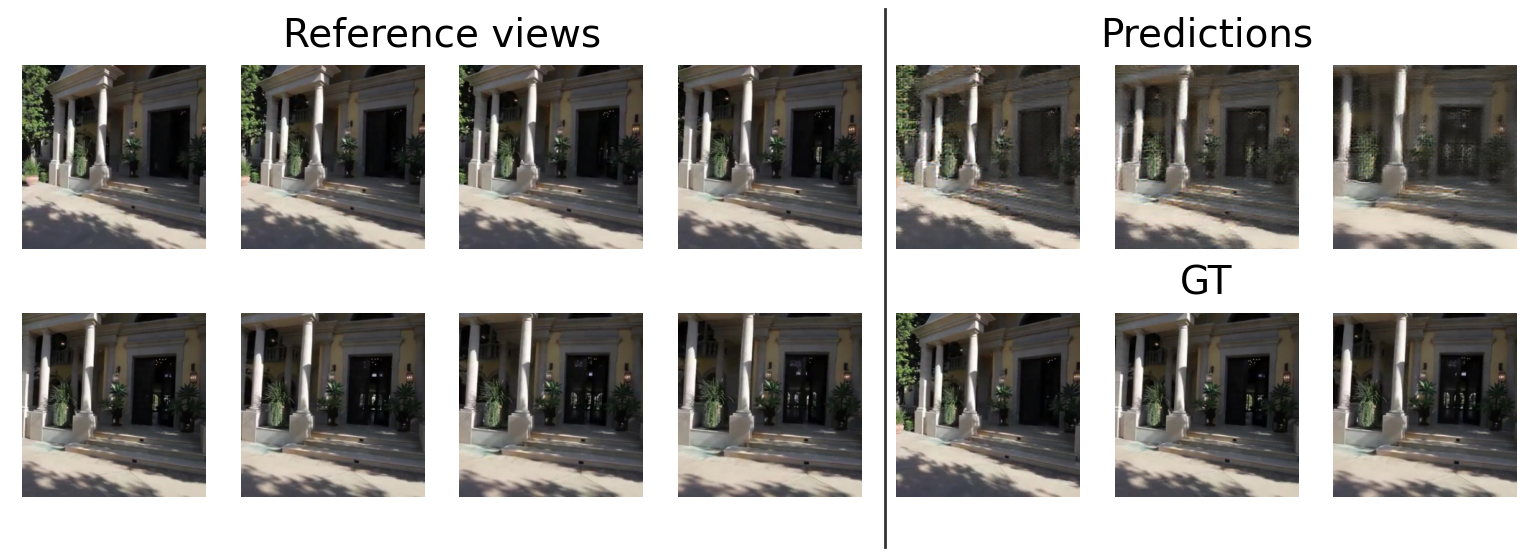

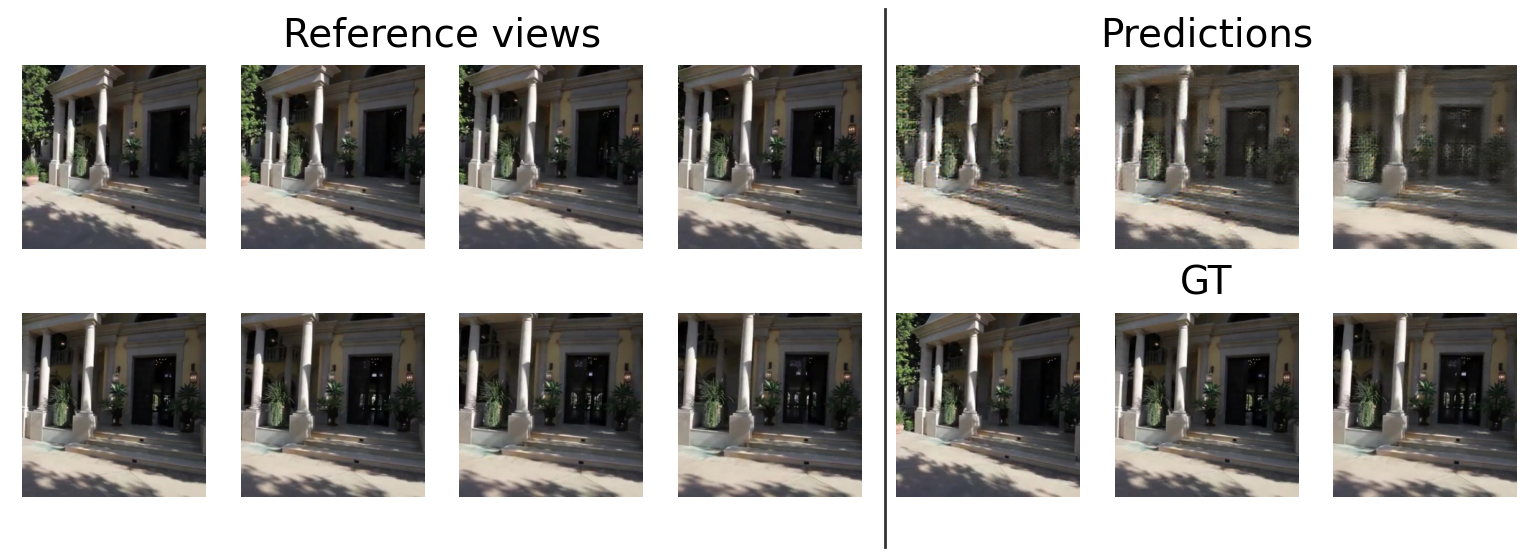

In [40]:
# folder                               reference_views           max_id  max_ssim           min_id  min_ssim           avg_id  avg_ssim
# LVSM-VAE fine-tuned on 4-references                2 ce8bc5948d0dd3f3  0.928025 ace3ec0961ae36c2  0.116508 dabd7fc58d2ae00b  0.612592
#    LVSM-VAE trained on 2-references                2 ce8bc5948d0dd3f3  0.933030 c4a26c35749d41bd  0.120769 81656a7e1b5e50f8  0.629539
# LVSM-VAE fine-tuned on 4-references                4 89eb71213e160ce0  0.939422 4befac16ffdf8489  0.117180 171fdcc554d303d8  0.675402
#    LVSM-VAE trained on 2-references                4 ce8bc5948d0dd3f3  0.942130 6e6ccb9822ed013e  0.095725 dde677478d8ca018  0.590735
# LVSM-VAE fine-tuned on 4-references                8 9dd571bfa9a0ef35  0.945701 4befac16ffdf8489  0.148136 f96049f4355544bd  0.693306
#    LVSM-VAE trained on 2-references                8 ce8bc5948d0dd3f3  0.934086 4befac16ffdf8489  0.068118 fb7719fc97e9f6e8  0.523269
# LVSM-VAE fine-tuned on 4-references               16 9dd571bfa9a0ef35  0.940695 4befac16ffdf8489  0.101100 9d8ca3b8ce050769  0.668387
#    LVSM-VAE trained on 2-references               16 ce8bc5948d0dd3f3  0.926411 4befac16ffdf8489  0.062010 7144a5e59d5f05c7  0.480059

# Saved: ssim_extremes_and_average_ids.csv

# ID = "ce8bc5948d0dd3f3" # langweililg: Glühbirne
# ID = "89eb71213e160ce0" # langweililg: Tür, sehr gleiche views
# ID = "9dd571bfa9a0ef35" # langweililg: Treppe

pc = "teampc"

evaluator.set_checkpoint(
    # f"/home/{pc}/LVSM-VAE/results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/ckpts/best_for_now/step-000870100.pt" # 2-ref
    f"/home/{pc}/LVSM-VAE/results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/ckpts/best_for_now/step-000887200.pt" # 4-ref
)

ID = "f27cb10112666229"
CTX = 8

res = evaluator.eval(
    scene_id=ID,
    eval_index_path=f"/home/{pc}/LVSM-VAE/assets/evaluation_index_re10k_context{CTX}.json",
)

res["ssim"]


plot_lvsm_scene_nice_fig(
    ref_px=res["ref_px"],
    out_px=res["out_px"],
    tar_px=res["tar_px"],
)

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def save_top5_plots(
    *,
    evaluator,
    csv_path: str,
    plots_root: str,
    group: str,                      # "max_ssim" | "min_ssim" | "avg_ssim"
    checkpoint_map: dict,            # {2: "/path/to/ckpt.pt", 4: "..."}
    eval_index_template: str,        # e.g. "/home/felix/LVSM-VAE/assets/evaluation_index_re10k_context{ctx}.json"
    inference_contexts=range(2, 17),
    top_k: int = 5,
    dpi: int = 200,
    overwrite: bool = False,
    show_inline: bool = False,       # optional: still show in notebook
):
    assert group in {"max_ssim", "min_ssim", "avg_ssim"}, group

    df = pd.read_csv(csv_path)

    # parse model ctx from folder label (expects a number in the label)
    def parse_model_ctx(label: str) -> int:
        import re
        m = re.search(r"(\d+)", str(label))
        if not m:
            raise ValueError(f"Could not parse model ctx from folder label: {label}")
        return int(m.group(1))

    prefix = group.split("_")[0]  # "max" | "min" | "avg"

    current_model_ctx = None

    if "reference_views" in df.columns:
        df = df[df["reference_views"].isin(list(inference_contexts))].copy()

    for _, row in df.iterrows():
        model_label = row["folder"]
        infer_ctx = int(row["reference_views"])
        model_ctx = parse_model_ctx(model_label)

        if model_ctx != current_model_ctx:
            if model_ctx not in checkpoint_map:
                raise KeyError(f"No checkpoint for model_ctx={model_ctx}. Have {sorted(checkpoint_map.keys())}")
            evaluator.set_checkpoint(checkpoint_map[model_ctx])
            current_model_ctx = model_ctx

        out_dir = os.path.join(
            plots_root,
            group,
            f"model_{model_ctx}ctx",
            f"inference_{infer_ctx}ctx",
        )
        os.makedirs(out_dir, exist_ok=True)

        eval_index_path = eval_index_template.format(ctx=infer_ctx)

        for k in range(1, top_k + 1):
            id_col = f"{prefix}{k}_id"
            if id_col not in row or pd.isna(row[id_col]):
                continue

            scene_id = str(row[id_col]).strip()
            out_path = os.path.join(out_dir, f"{scene_id}.png")

            if (not overwrite) and os.path.exists(out_path):
                continue

            res = evaluator.eval(scene_id=scene_id, eval_index_path=eval_index_path)

            # IMPORTANT: make figure, save *that* figure
            fig = plot_lvsm_scene_nice_fig(
                ref_px=res["ref_px"],
                out_px=res["out_px"],
                tar_px=res["tar_px"],
            )

            fig.savefig(out_path, dpi=dpi, bbox_inches="tight")

            if show_inline:
                plt.show()

            plt.close(fig)

    print(f"Done. Saved plots under: {plots_root}")


In [14]:
checkpoint_map = {
    2: "/home/felix/LVSM-VAE/results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/ckpts/best_for_now/step-000870100.pt",  # model trained for 2ctx
    4: "/home/felix/LVSM-VAE/results/nvs/VAE/release-1gpus-b8-s1-80k-CAMRAY-PROPE/ckpts/best_for_now/step-000887200.pt",  # model trained for 4ctx    
}

save_top5_plots(
    evaluator=evaluator,
    csv_path="/home/felix/LVSM-VAE/notebooks/results/one_scene_eval/ssim_extremes_and_average_ids.csv",
    plots_root="/home/felix/LVSM-VAE/notebooks/results/one_scene_eval/plots",
    group="avg_ssim",
    checkpoint_map=checkpoint_map,
    inference_contexts=range(2, 9),
    eval_index_template="/home/felix/LVSM-VAE/assets/evaluation_index_re10k_context{ctx}.json",
    top_k=15,
    overwrite=True,
    show_inline=False,   # set True if you also want to see them
)

/tmp/ipykernel_66564/1186112850.py:109: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path, map_location="cpu")
/tmp/ipykernel_66564/1929457517.py:94: User

Done. Saved plots under: /home/felix/LVSM-VAE/notebooks/results/one_scene_eval/plots


# scatter plots

In [114]:
import numpy as np
# df_a # LVSM-VAE trained on 2 references
# df_b # LVSM-VAE fine-tuned on 4 references
# df_c # LVSM-VAE fine-tuned on 8 references
# df_d # LVSM PRoPE - trained on 2 references

results_file = "../results/performance_comparison/260129_results_6.json"

mem_df = pd.read_json(results_file)

scatter_df = pd.DataFrame(columns=["label","forward_mem","SSIM","LPIPS","PSNR"])


def get_values(name, df, space, views):
    forward_mem = np.mean(mem_df.query(f"model_space == '{space}' and layers == 6 and dim_feedforward == 1024 and ref_views == {views} and scale_factor == 1")["forward_memory_mb"])
    PSNR = df.query(f"reference_views == {views}")["psnr"].iloc[0]
    SSIM = df.query(f"reference_views == {views}")["ssim"].iloc[0]
    LPIPS = df.query(f"reference_views == {views}")["lpips"].iloc[0]
    return [name, forward_mem, SSIM, LPIPS, PSNR]

scatter_df = pd.concat([scatter_df, pd.DataFrame([get_values("LVSM PRoPE (ctx = 2)",df_d, 'PX', 2)], columns=scatter_df.columns)],ignore_index=True)
# scatter_df = pd.concat([scatter_df, pd.DataFrame([get_values("LVSM PRoPE (ctx = 4)",df_d, 'PX', 4)], columns=scatter_df.columns)],ignore_index=True)
scatter_df = pd.concat([scatter_df, pd.DataFrame([get_values("LVSM-VAE-ft8 (ctx = 8)",df_c, 'VAE', 8)], columns=scatter_df.columns)],ignore_index=True)
scatter_df = pd.concat([scatter_df, pd.DataFrame([get_values("LVSM-VAE-ft4 (ctx = 4)",df_b, 'VAE', 4)], columns=scatter_df.columns)],ignore_index=True)
scatter_df = pd.concat([scatter_df, pd.DataFrame([get_values("LVSM-VAE (ctx = 2)",df_a, 'VAE', 2)], columns=scatter_df.columns)],ignore_index=True)

/tmp/ipykernel_349161/2083004574.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scatter_df = pd.concat([scatter_df, pd.DataFrame([get_values("LVSM PRoPE (ctx = 2)",df_d, 'PX', 2)], columns=scatter_df.columns)],ignore_index=True)


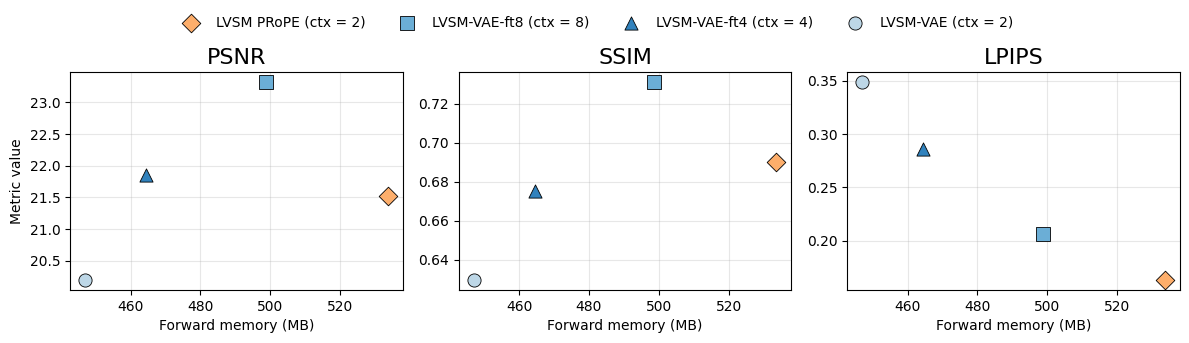

In [123]:
markers = {
    "LVSM-VAE (ctx = 2)":       "o",   # circle
    "LVSM-VAE-ft8 (ctx = 8)":   "s",   # square
    "LVSM-VAE-ft4 (ctx = 4)":   "^",   # triangle up    
    "LVSM PRoPE (ctx = 2)":     "D",   # diamond
    "LVSM PRoPE (ctx = 4)":     "o",   # diamond
}

colors = {
    "LVSM-VAE (ctx = 2)":       "#bdd7e7",
    "LVSM-VAE-ft8 (ctx = 8)":   "#6baed6",
    "LVSM-VAE-ft4 (ctx = 4)":   "#3182bd",
    "LVSM PRoPE (ctx = 2)":     "#fdae6b",
}


import matplotlib.pyplot as plt

metrics = ["PSNR", "SSIM", "LPIPS"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)

handles_by_label = {}

for ax, m in zip(axes, metrics):
    for _, row in scatter_df.iterrows():
        label = row["label"]

        h = ax.scatter(
            row["forward_mem"],
            row[m],
            s=90,
            marker=markers.get(label, "o"),
            color=colors.get(label, "gray"),
            edgecolors="black",
            linewidths=0.6,
            zorder=3,
            label=label,
        )

        # capture one handle per label for the legend
        if label not in handles_by_label:
            handles_by_label[label] = h

    ax.set_title(m, fontsize=16)
    ax.set_xlabel("Forward memory (MB)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Metric value")

fig.legend(
    handles_by_label.values(),
    handles_by_label.keys(),
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.15),
)

fig.tight_layout(rect=[0, 0, 1, 1.05])
plt.show()
